#📌 Extracción

In [4]:
import requests
import pandas as pd

In [6]:
# URL del archivo JSON en GitHub
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Solicitar los datos desde la URL
response = requests.get(url)
response.raise_for_status()  # Si hay un error HTTP, se lanzará una excepción

# Convertir la respuesta JSON en un diccionario/lista
data = response.json()

# Paso 4: Crear el DataFrame
df = pd.DataFrame(data)

In [3]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [7]:
#Normalizar columnas anidadas
customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

In [8]:
#Concatenar todo en un solo DataFrame
df = pd.concat(
    [df[['customerID', 'Churn']], customer_df, phone_df, internet_df, account_df],
    axis=1
)

In [ ]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

## **Identificar las columnas más relevantes para análisis de evasión**

### *Demográficas*: gender, SeniorCitizen, Partner, Dependents

### *Antigüedad*: tenure

### *Servicios* contratados: PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

### *Contrato y facturación*: Contract, PaperlessBilling, PaymentMethod

### *Financieras*: Charges.Monthly, Charges.Total

### *Variable objetivo*: Churn

In [9]:
# Ver nombres de columnas y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
# Convertir columnas numéricas
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)
df['tenure'] = df['tenure'].astype(int)
df['Charges.Monthly'] = df['Charges.Monthly'].astype(float)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

# Convertir a categoría (o string) todas las variables categóricas
categoricas = [
    'customerID', 'Churn', 'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in categoricas:
    df[col] = df[col].astype('category')

# Verificar cambios
df.dtypes


,0
customerID,category
Churn,category
gender,category
SeniorCitizen,int64
Partner,category
Dependents,category
tenure,int64
PhoneService,category
MultipleLines,category
InternetService,category


In [10]:
df.nunique()

,0
customerID,7267
Churn,3
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3


In [11]:
# Limpiar espacios y poner en minúsculas
df["Churn"] = df["Churn"].astype(str).str.strip().str.lower()

# Reemplazar variaciones por 'Yes' o 'No'
df["Churn"] = df["Churn"].replace({
    'yes': 'Yes',
    'no': 'No',
    'nan': None,
    '': None
})

# Verificar resultado
df["Churn"].unique()

array(['No', 'Yes', None], dtype=object)

In [12]:
df = df[df['Churn'].notna()]

In [13]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [14]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [15]:
# Conteo de valores nulos por columna
df.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [16]:
# Ver todos los valores distintos en la columna
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
# Filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


In [17]:
# Crear columna Cuentas_Diarias asumiendo 30 días por mes
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

# Redondear a 2 decimales
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].round(2)

# Verificar
df[['Charges.Monthly', 'Cuentas_Diarias']].head()


,Charges.Monthly,Cuentas_Diarias
0,65.6,2.19
1,59.9,2.00
2,73.9,2.46
3,98.0,3.27
4,83.9,2.80


#📊 Carga y análisis

In [18]:
# Análisis descriptivo general
df.describe()

,SeniorCitizen,tenure,Charges.Monthly,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2.158675
std,0.368612,24.559481,30.090047,1.003088
min,0.000000,0.000000,18.250000,0.610000
25%,0.000000,9.000000,35.500000,1.180000
50%,0.000000,29.000000,70.350000,2.340000
75%,0.000000,55.000000,89.850000,2.990000
max,1.000000,72.000000,118.750000,3.960000


In [19]:
import matplotlib.pyplot as plt

In [20]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


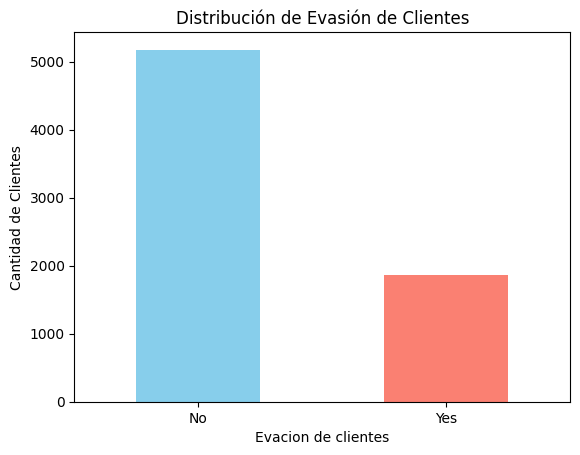

In [21]:
# Gráfico de barras
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Evasión de Clientes')
plt.xlabel('Evacion de clientes')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.show()

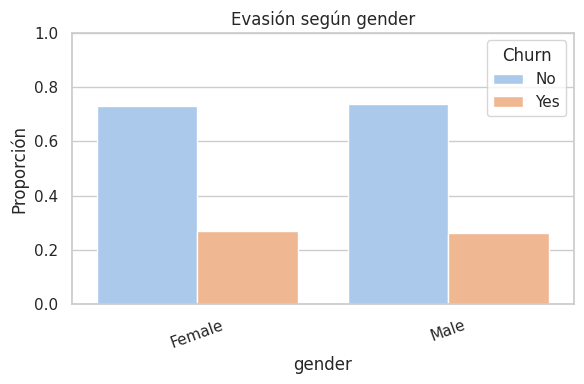

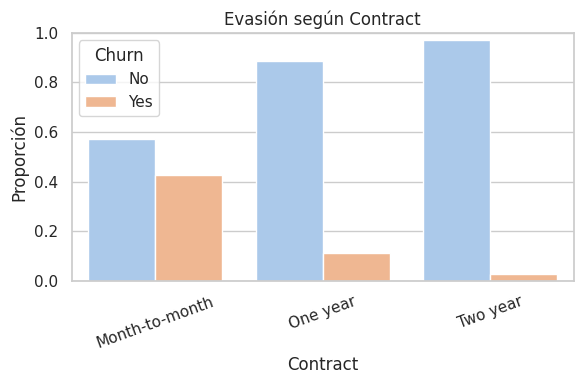

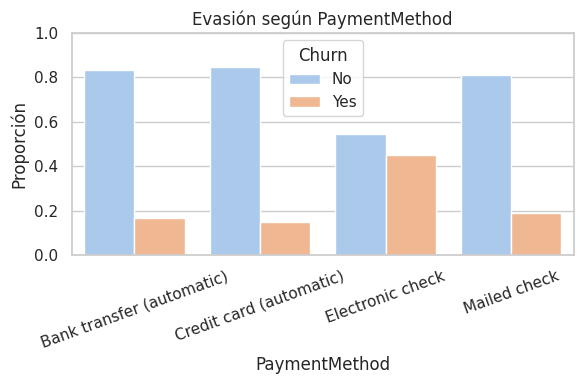

In [23]:
import seaborn as sns
# Lista de variables categóricas a analizar
categoricas = ["gender", "Contract", "PaymentMethod"]
# Configuración de gráficos
sns.set(style="whitegrid", palette="pastel")

for col in categoricas:
    plt.figure(figsize=(6,4))
    # Conteo proporcional por categoría y churn
    prop = (df.groupby(col)['Churn']
              .value_counts(normalize=True)
              .rename("proportion")
              .reset_index())

    # Gráfico
    sns.barplot(data=prop, x=col, y="proportion", hue="Churn")
    plt.title(f"Evasión según {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    plt.legend(title="Churn")
    plt.tight_layout()
    plt.show()

#📄Informe final

# 📑 Informe de Análisis de Evasión de Clientes (Churn)

## 🔹 Introducción  
El objetivo de este análisis es comprender el fenómeno de **evasión de clientes (Churn)** en la empresa TelecomX LATAM.  
El *churn* se refiere a los clientes que cancelan sus servicios, lo que impacta directamente en los ingresos y la estabilidad de la compañía.  

Este estudio busca:  
- Identificar patrones de comportamiento asociados a la evasión.  
- Analizar variables demográficas, contractuales, de uso de servicios y de facturación.  
- Proporcionar insights y recomendaciones estratégicas para reducir la tasa de deserción.  

---

## 🔹 Limpieza y Tratamiento de Datos  
- Importación de datos desde un archivo JSON alojado en GitHub.  
- Normalización de columnas anidadas (cliente, teléfono, internet y cuenta).  
- Corrección de tipos de datos:  
  - Variables numéricas: `SeniorCitizen`, `tenure`, `Charges.Monthly`, `Charges.Total`.  
  - Variables categóricas: género, contrato, métodos de pago, etc.  
- Estandarización de la variable **Churn** con valores `Yes` y `No`.  
- Eliminación de valores nulos y duplicados.  
- Creación de la variable adicional `Cuentas_Diarias` (costo promedio diario).  

---

## 🔹 Análisis Exploratorio de Datos (EDA)  

### 1. Distribución General  
- Total de clientes: **7043**  
- Clientes que abandonaron (Churn = Yes): **1869** (~26.5%)  
- Clientes que permanecen (Churn = No): **5174** (~73.5%)  

📊 *Gráfico de distribución de churn:*  
*(Insertar gráfico de barras generado en el análisis)*  

### 2. Variables Clave  
- **Contrato:** Los clientes con contratos mensuales presentan mayor tasa de churn.  
- **Método de pago:** Los clientes que usan *electronic check* tienden a desertar más.  
- **Internet Service:** El servicio de *Fiber optic* muestra una tasa de evasión más alta que DSL.  
- **Tenure:** Los clientes con menor antigüedad (menos de 1 año) son los que más abandonan.  

---

## 🔹 Conclusiones e Insights  

1. **La tasa de churn es del 26.5%**, lo que representa un reto importante para la empresa.  
2. El **tipo de contrato** es un factor crítico: los clientes con contratos mensuales tienen más probabilidades de abandonar.  
3. El **método de pago** influye: *electronic check* está asociado con mayor evasión.  
4. El **servicio de internet por fibra óptica** presenta una tasa de churn mayor que DSL.  
5. Los clientes con **baja antigüedad (tenure corto)** son los más vulnerables a desertar.  

---

## 🔹 Recomendaciones Estratégicas  

1. **Fidelización temprana:** Programas de retención para clientes con menos de un año de servicio.  
2. **Incentivos por contratos largos:** Ofrecer descuentos o beneficios para promover contratos anuales o bianuales.  
3. **Mejorar experiencia en Fiber Optic:** Detectar y resolver problemas técnicos que generan deserción en este segmento.  
4. **Optimizar métodos de pago:** Promover medios de pago más estables (tarjeta de crédito/débito, transferencias).  
5. **Analítica predictiva:** Implementar modelos de *machine learning* que anticipen el churn y activen alertas tempranas.  
